# Bias-Variance Tradeoff

## Overview

Every model's prediction error decomposes into three components:

```
Expected MSE = Bias² + Variance + Irreducible noise
```

| Component | Meaning | Reduced by |
|---|---|---|
| Bias² | Systematic underfit | More complex model |
| Variance | Sensitivity to training data | Regularisation, more data |
| Irreducible noise | Inherent data randomness | Cannot be reduced |

**Key implications:**
- Simpler models: high bias, low variance (underfit)
- Complex models: low bias, high variance (overfit)
- The sweet spot minimises total test error
- More training data reduces variance but not bias
- Regularisation trades a little bias for a large variance reduction

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, learning_curve
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

rng = np.random.default_rng(42)
import warnings
# True function: moderate non-linearity
def true_fn(x):
    return 2*np.sin(x) + 0.5*x

n_train = 60
X_train = rng.uniform(0, 8, n_train).reshape(-1,1)
y_train = true_fn(X_train.ravel()) + rng.normal(0, 1.0, n_train)
X_test  = np.linspace(0, 8, 300).reshape(-1,1)
y_test  = true_fn(X_test.ravel())
print(f"Train n={n_train}, noise SD=1.0")

Train n=60, noise SD=1.0


---
## Polynomial Degree: Bias-Variance Tradeoff in Action

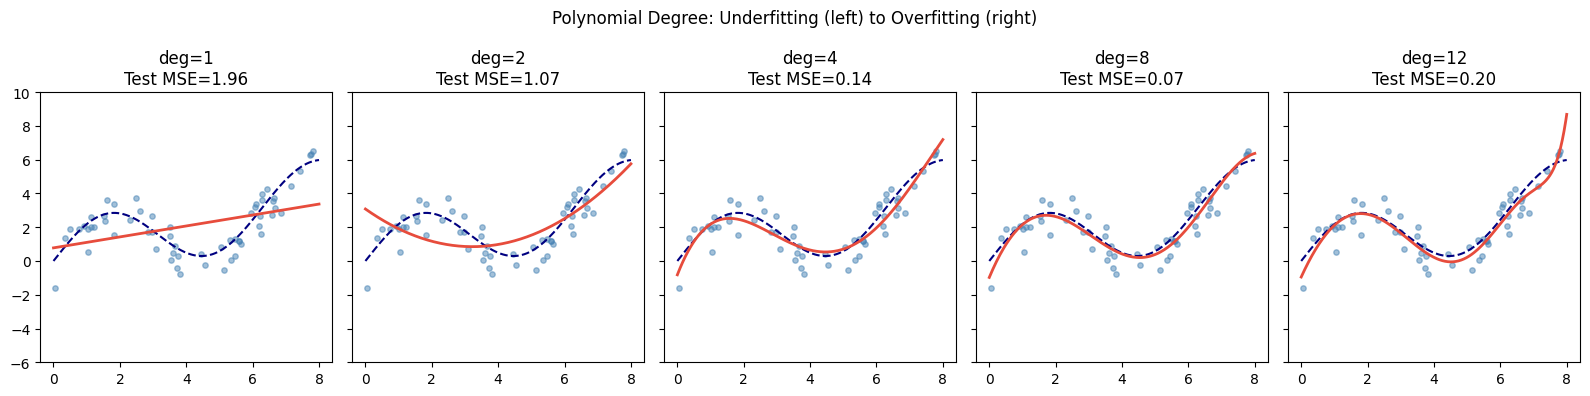

In [2]:
degrees = [1, 2, 4, 8, 12]
fig, axes = plt.subplots(1, len(degrees), figsize=(16,4), sharey=True)
train_mses, test_mses = [], []
for ax, deg in zip(axes, degrees):
    pipe = Pipeline([("poly", PolynomialFeatures(deg, include_bias=False)),
                     ("scaler", StandardScaler()),
                     ("ridge", Ridge(alpha=1e-3))])
    pipe.fit(X_train, y_train)
    y_pred_train = pipe.predict(X_train)
    y_pred_test  = pipe.predict(X_test)
    tr_mse = mean_squared_error(y_train, y_pred_train)
    te_mse = mean_squared_error(y_test,  y_pred_test)
    train_mses.append(tr_mse); test_mses.append(te_mse)
    ax.scatter(X_train, y_train, s=15, alpha=0.5, color="steelblue")
    ax.plot(X_test, y_test,       color="navy",    lw=1.5, linestyle="--", label="True")
    ax.plot(X_test, y_pred_test,  color="#e74c3c", lw=2,   label="Model")
    ax.set_title(f"deg={deg}\nTest MSE={te_mse:.2f}")
    ax.set_ylim(-6, 10)
plt.suptitle("Polynomial Degree: Underfitting (left) to Overfitting (right)")
plt.tight_layout(); plt.show()

---
## Bias-Variance Decomposition

In [3]:
# Empirical bias-variance decomposition via bootstrap
def bv_decomp(degree, n_boot=200):
    preds = []
    for _ in range(n_boot):
        idx = rng.integers(0, n_train, n_train)
        Xb, yb = X_train[idx], y_train[idx]
        poly = PolynomialFeatures(degree, include_bias=False)
        Xb_poly = poly.fit_transform(Xb)
        scaler = StandardScaler().fit(Xb_poly)
        Xb_scaled = scaler.transform(Xb_poly)
        # check condition number and warn if ill-conditioned
        cond = np.linalg.cond(Xb_scaled)
        if cond > 1e12:
            warnings.warn(f"High condition number for degree={degree}: {cond:.2e}")
        try:
            ridge = Ridge(alpha=1e-3)
            ridge.fit(Xb_scaled, yb)
            # transform X_test the same way
            Xtest_poly = poly.transform(X_test)
            Xtest_scaled = scaler.transform(Xtest_poly)
            preds.append(ridge.predict(Xtest_scaled))
        except Exception:
            pass
    preds = np.array(preds)
    bias2   = np.mean((preds.mean(axis=0) - y_test)**2)
    variance = preds.var(axis=0).mean()
    return bias2, variance

print(f"{'Degree':>8} {'Bias2':>10} {'Variance':>10} {'Total':>10}")
for deg in [1, 2, 4, 8, 12]:
    b2, var = bv_decomp(deg)
    print(f"{deg:>8} {b2:>10.3f} {var:>10.3f} {b2+var:>10.3f}")

  Degree      Bias2   Variance      Total
       1      1.953      0.089      2.041
       2      1.090      0.127      1.216
       4      0.152      0.059      0.211
       8      0.060      0.219      0.280
      12      0.187      0.136      0.323


---
## Learning Curves

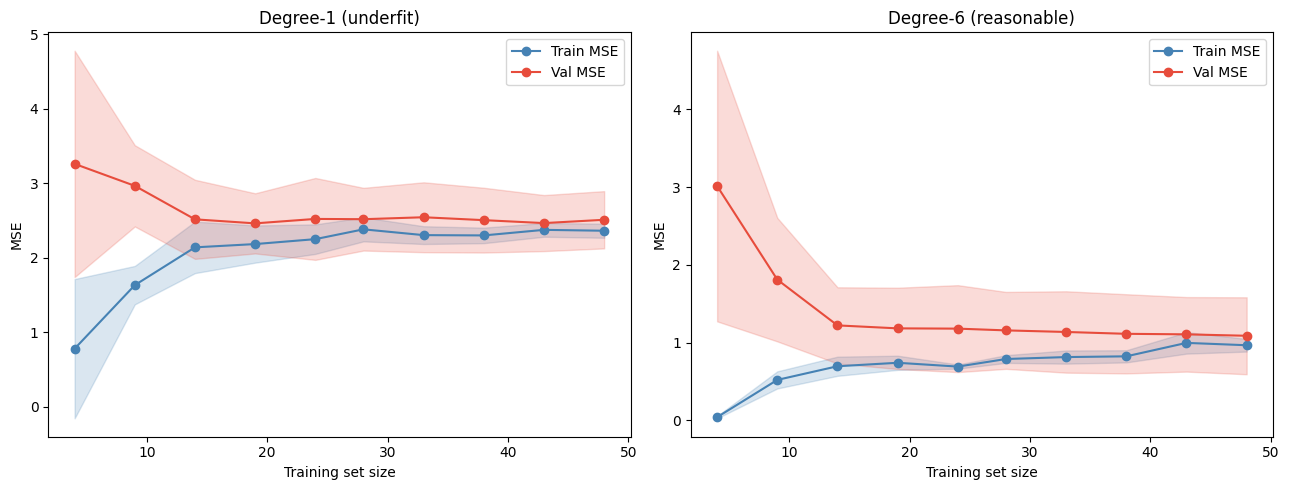

Underfit: train and val MSE both high and converge quickly
Overfit:  train MSE low, val MSE high, large gap


In [4]:
fig, axes = plt.subplots(1,2,figsize=(13,5))
for ax, (label, estimator) in enumerate([
        ("Degree-1 (underfit)",  Pipeline([("poly", PolynomialFeatures(1, include_bias=False)),("scaler", StandardScaler()),("r", Ridge(1e-3))])),
        ("Degree-6 (reasonable)", Pipeline([("poly", PolynomialFeatures(6, include_bias=False)),("scaler", StandardScaler()),("r", Ridge(0.1))]))]):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X_train, y_train,
        train_sizes=np.linspace(0.1,1.0,10),
        cv=5, scoring="neg_mean_squared_error", n_jobs=-1)
    tr_mean  = -train_scores.mean(axis=1)
    val_mean = -val_scores.mean(axis=1)
    tr_std   = train_scores.std(axis=1)
    val_std  = val_scores.std(axis=1)
    axes[ax].plot(train_sizes, tr_mean,  "o-", color="steelblue", label="Train MSE")
    axes[ax].plot(train_sizes, val_mean, "o-", color="#e74c3c",   label="Val MSE")
    axes[ax].fill_between(train_sizes, tr_mean-tr_std,   tr_mean+tr_std,   alpha=0.2, color="steelblue")
    axes[ax].fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.2, color="#e74c3c")
    axes[ax].set_xlabel("Training set size"); axes[ax].set_ylabel("MSE")
    axes[ax].set_title(label); axes[ax].legend()
plt.tight_layout(); plt.show()
print("Underfit: train and val MSE both high and converge quickly")
print("Overfit:  train MSE low, val MSE high, large gap")

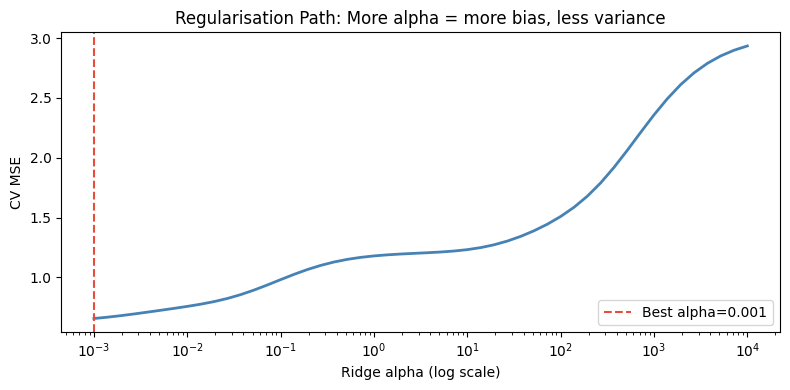

In [5]:
# Regularisation: bias-variance tradeoff via Ridge alpha
alphas = np.logspace(-3, 4, 50)
cv_mses = []
for alpha in alphas:
    pipe = Pipeline([("poly", PolynomialFeatures(8, include_bias=False)),
                     ("scaler", StandardScaler()),
                     ("ridge", Ridge(alpha=alpha))])
    scores = cross_val_score(pipe, X_train, y_train,
                              cv=5, scoring="neg_mean_squared_error")
    cv_mses.append(-scores.mean())
best_alpha = alphas[np.argmin(cv_mses)]
plt.figure(figsize=(8,4))
plt.semilogx(alphas, cv_mses, color="steelblue", lw=2)
plt.axvline(best_alpha, color="#e74c3c", lw=1.5, linestyle="--",
            label=f"Best alpha={best_alpha:.3f}")
plt.xlabel("Ridge alpha (log scale)"); plt.ylabel("CV MSE")
plt.title("Regularisation Path: More alpha = more bias, less variance")
plt.legend(); plt.tight_layout(); plt.show()

---

## Common Pitfalls

**1. Diagnosing overfitting only from training accuracy**  
A model with 99% training accuracy and 65% test accuracy is clearly overfitting, but training accuracy alone conceals this. Always compare training and test (or CV) performance together. A large gap is the signature of high variance.

**2. Adding more data to fix a high-bias (underfit) model**  
Learning curves for an underfit model show train and validation MSE converging at a high level — adding more data just confirms the model is wrong. Fix bias by increasing model complexity or engineering better features, not by collecting more data.

**3. Using test set performance for regularisation tuning**  
If you choose the Ridge alpha that minimises test MSE, the test set has been used for model selection and no longer provides an unbiased performance estimate. Use cross-validation for tuning; reserve the test set for a single final evaluation.

**4. Ignoring variance when choosing between models of similar bias**  
Two models with similar mean CV error may have very different CV standard deviations. A model with slightly higher mean but much lower SD is often preferable in practice — it generalises more reliably across different samples.

**5. Assuming regularisation always helps**  
Regularisation reduces variance at the cost of increased bias. For large datasets where variance is already low, heavy regularisation can hurt by introducing unnecessary bias. Always tune regularisation strength via CV rather than applying it by default.

---
*python_methods_library - Samantha McGarrigle*